In [1]:
import torch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
# for reading HDF5 files
import h5py
import os

In [2]:
# import region bounds
from regions import ROSS_BOUNDS

# assign region bounds
x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

# Thickening rates 

For consistency with the becnhmark bmb map published by **Adusumilli et al. 2020**, we use their provided ice thickening rates.

## References and links:
- Paper: *Adusumilli, Susheel, et al. "Interannual variations in meltwater input to the Southern Ocean from Antarctic ice shelves." Nature geoscience 13.9 (2020): 616-620.* [Link to paper on Nature.](https://www.nature.com/articles/s41561-020-0616-z)
- [Link to UCSD data repository](https://library.ucsd.edu/dc/object/bb0448974g). Select Component 2 for ice shelf surface elevation changes.
- [Link to accompanying UCSD Scripps glaciology Github repository](https://github.com/sioglaciology/ice_shelf_change). Refer to *read_height_change_file.ipynb* notebook for preprocessing pipeline.

## Download data

Via the terminal, navigate to the destination folde to hold the file and and download the file with the following command:  
  
``wget https://library.ucsd.edu/dc/object/bb0448974g/_2_1.h5/download -O ANT_iceshelf_height_changes_RA_1994_2018_v0.h5``

## Output

| Field    | Description                                                                           |
| -------- | ------------------------------------------------------------------------------------- |
| `time`   | 1994.16 – 2018.75 average                                                             |
| `x`, `y` | Already in Antarctic Polar Stereographic Projection [EPSG:3031](https://epsg.io/3031) |
| `dhdt`    | m ice equivalent (i.e.) per year**                                                   |

# Load h5 file

In [3]:
# Specify your local path to the HDF5 file
path_to_hc_file = "/home/kim/data/adusumulli/ANT_iceshelf_height_changes_RA_1994_2018_v0.h5"

adusumulli_height_change = h5py.File(path_to_hc_file,'r')

# Inspect the contents of the HDF5 file
with h5py.File(path_to_hc_file, 'r') as f:
    print("Top-level keys:", list(f.keys()))

Top-level keys: ['h_alt', 'h_firn', 'smb_discharge', 'time', 'uncert_alt', 'uncert_firn', 'x', 'y']


## Print structure and meta data

In [4]:
def print_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name} | Shape: {obj.shape} | Type: {obj.dtype}")
    elif isinstance(obj, h5py.Group):
        print(f"Group: {name}")

with h5py.File(path_to_hc_file, 'r') as f:
    f.visititems(print_structure)

print("")
with h5py.File(path_to_hc_file, 'r') as f:
    # List of datasets to inspect
    datasets = ['h_alt', 'h_firn']
    
    for ds_name in datasets:
        if ds_name in f:
            ds = f[ds_name]
            print(f"\n--- Metadata for '{ds_name}' ---")
            for key, value in ds.attrs.items():
                print(f"  {key}: {value}")
        else:
            print(f"\n[!] Warning: {ds_name} not found in file.")

Dataset: h_alt | Shape: (107, 436, 510) | Type: float64
Dataset: h_firn | Shape: (107, 436, 510) | Type: float64
Dataset: smb_discharge | Shape: (107, 436, 510) | Type: float64
Dataset: time | Shape: (1, 107) | Type: float64
Dataset: uncert_alt | Shape: (107, 436, 510) | Type: float64
Dataset: uncert_firn | Shape: (436, 510) | Type: float64
Dataset: x | Shape: (436, 510) | Type: float64
Dataset: y | Shape: (436, 510) | Type: float64


--- Metadata for 'h_alt' ---
  description: Ice shelf surface height change from altimetry
  units: m, anomaly relative to to 1994 value

--- Metadata for 'h_firn' ---
  description: m, anomaly relative to to 1994 value


# Define conversion factors

In [5]:
# ocean water (ow) density in kg/m^3
rho_ow = 1028
# ice density in kg/m^3
rho_ice = 917

print("Freeboard to thickness conversion factor:", (1 + rho_ice/ (rho_ow - rho_ice)))

Freeboard to thickness conversion factor: 9.26126126126126


# Load the data from the file

In [6]:
# Shape: (436, 510) (x, y)
x = np.array(adusumulli_height_change["/x"])
# Shape: (436, 510) (x, y)
y = np.array(adusumulli_height_change["/y"]) 
# Shape: (107,) (time)
t = np.array(adusumulli_height_change["/time"]) 

# Extract grid spacing
print("Grid spacing in x (m):", x[0, 1] - x[0, 0])
print("Grid spacing in y (m):", y[1, 0] - y[0, 0])

# Freeboard change
# Shape: (107, 436, 510) (time, x, y)
delta_h_altimetry = np.array(adusumulli_height_change['/h_alt'])
# NOTE: freeboard change (total) relative to 1994
print("Mean freeboard change at time index 7 (1994):")
print(np.nanmean(delta_h_altimetry[7, :, :]).item())

# Firn correction
# Shape: (107, 436, 510) (time, x, y)
delta_h_firn_correction = np.array(adusumulli_height_change['/h_firn'])

# Firn adjust and convert freeboard to thickness change (hydrostatic equilibrium)
# scales by ~ 9.26
# NOTE: output is in ice equivalent
thickness_change = (delta_h_altimetry - delta_h_firn_correction) * (1 + rho_ice/ (rho_ow - rho_ice))

Grid spacing in x (m): 10000.0
Grid spacing in y (m): 10000.0
Mean freeboard change at time index 7 (1994):
0.0


### Note: Since the data is provided as ice surface elevation relative to 1994 (pre CryoSat-2) coverage is limited to 81.5 degrees.

## Visualise one time slice (2018 relative to 1994)

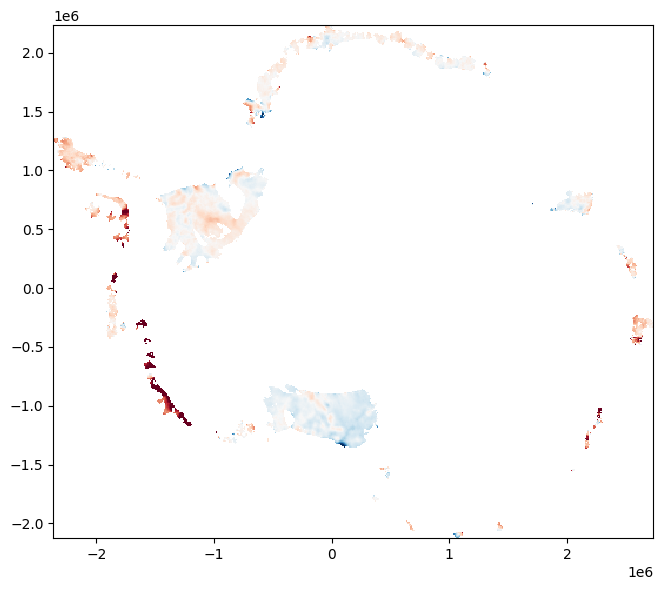

In [7]:
time_slice = 106

plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    x,
    y,
    thickness_change[time_slice, :, :],  # convert from mm to m
    cmap = "RdBu",
    vmin = -50,
    vmax = 50,
    shading = "auto"    
)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

# Bilinear interpolation to target grid

In [8]:
# 2D slice at time index 106
print("Time corresponding to index 106:", t[0, 106].item())
tc_106 = np.asarray(thickness_change[106, :, :])

# Ensure 1D x/y axes (works if x,y are already 1D; if they're 2D meshgrids, takes the axis vectors)
x1 = np.asarray(x).squeeze()
y1 = np.asarray(y).squeeze()
if x1.ndim == 2: x1 = x1[0, :]
if y1.ndim == 2: y1 = y1[:, 0]

# Wrap in xarray and interpolate onto target grid
thickness_change_da = xr.DataArray(
    tc_106,
    dims = ("y", "x"),
    coords = {"x": x1, "y": y1},
    name = "thickness_change",
)

# INTERPOLATE onto target grid with bilinear interpolation
target_grid_mask = xr.load_dataset("data/target_grid_mask.nc")

thickness_change_on_target = thickness_change_da.interp(
    x = target_grid_mask["x"],
    y = target_grid_mask["y"],
    method = "linear",
)

# Put into a Dataset and attach mask (same pattern as your SMB example)
thickness_change_on_target = thickness_change_on_target.to_dataset(name = "thickness_change")
thickness_change_on_target["mask"] = target_grid_mask["mask"]

# Inspect
thickness_change_on_target

Time corresponding to index 106: 2018.91232876712


<xarray.Dataset> Size: 36MB
Dimensions:           (x: 2000, y: 2000)
Coordinates:
  * x                 (x) float32 8kB -5.998e+05 -5.992e+05 ... 3.998e+05
  * y                 (y) float32 8kB -4.002e+05 -4.008e+05 ... -1.4e+06
Data variables:
    thickness_change  (y, x) float64 32MB nan nan nan nan ... nan nan nan nan
    mask              (y, x) int8 4MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0

# Visualise Ross thickness change 1994 - 2018

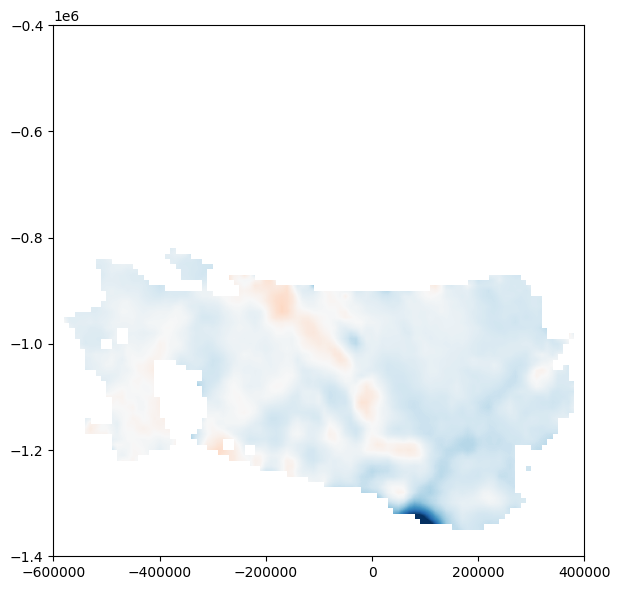

In [9]:
# Plot
# NOTE: matches map: https://github.com/sioglaciology/ice_shelf_change/blob/master/read_height_change_file.ipynb
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    thickness_change_on_target.x,
    thickness_change_on_target.y,
    thickness_change_on_target.thickness_change,
    cmap = "RdBu",
    vmin = -50,
    vmax = 50,
    shading = "auto"    
)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()
# NOTE: Ross is growing (positive thickness change)

# Convert to yearly mean rate

Number of years between index 7 and 106: 24.750684931503656


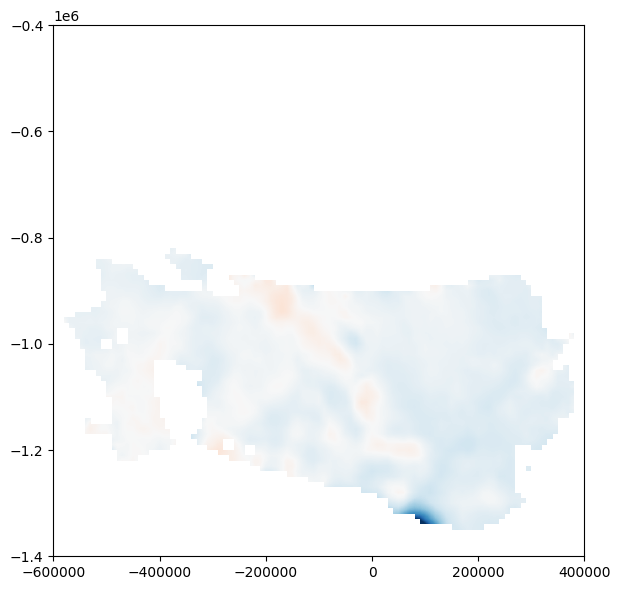

In [10]:
years = t[0, 106].item() - t[0, 7].item()
print("Number of years between index 7 and 106:", years)

# Plot
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    thickness_change_on_target.x,
    thickness_change_on_target.y,
    thickness_change_on_target.thickness_change / years,  # convert to mean rate over the number of years
    cmap = "RdBu",
    # NOTE: adjust color scale for mean rate
    vmin = -3,
    vmax = 3,
    shading = "auto"    
)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

## Load MODIS MOA background for visualisation

In [ ]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)

# Visualise data with background

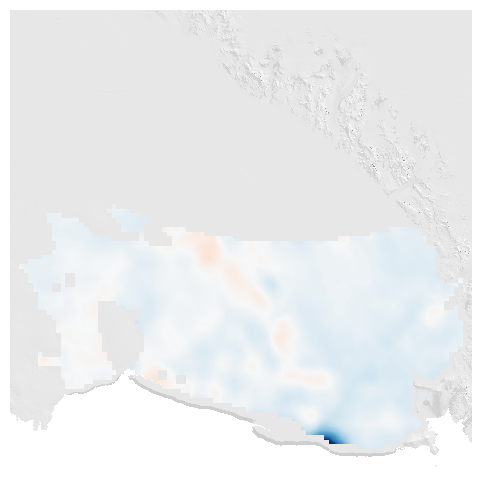

In [ ]:
vis_again = True

# Only rerun if needed
if vis_again :
    fig, ax = plt.subplots(figsize = (8, 6))

    # 1) MODIS as background (draw first)
    ax.pcolormesh(
        modis_ross[0],
        modis_ross[1], 
        modis_ross[2],
        cmap = "gray",
        # softer greys
        vmin = -30_000, 
        vmax = 30_000,
        # as less saturated background
        alpha = 0.4,
        zorder = 0,
    )

    # 2) SMB on top (draw second)
    pcm = ax.pcolormesh(
        thickness_change_on_target.x,
        thickness_change_on_target.y,
        # dh/dt where t is a year
        thickness_change_on_target.thickness_change / years,  # convert to mean rate over the number of years
        cmap = "RdBu",
        # fixed scale
        vmin = -3,
        vmax = 3,
        shading = "auto",
        alpha = 1.0,
        zorder = 1,
    )

    ax.set_aspect("equal")
    ax.set_axis_off()

    fig.savefig("figures/dhdt_adusumilli_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
    plt.show()

# Add to combined dataset

## Units

| Field    | Description                                                                           |
| -------- | ------------------------------------------------------------------------------------- |
| `time`   | 1994.16 – 2018.75 average                                                             |
| `x`, `y` | Already in Antarctic Polar Stereographic Projection [EPSG:3031](https://epsg.io/3031) |
| `dhdt`    | m ice equivalent (i.e.) per year**                                                   |

In [ ]:
path = "data/fluxnet_div_ross.nc"

# 1) Open -> load into memory -> close file handle
with xr.open_dataset(path) as _ds:
    ds = _ds.load()

# 2) Add variable
# NOTE: Transpose
ds["adusumilli_dhdt"] = (("y", "x"), thickness_change_on_target["thickness_change"].values.T / years)
ds["adusumilli_dhdt"].attrs.update({
    "long_name": "Adusumilli thickness change derived dh/dt 1994.16–2018.75",
    "units": "m i.e. yr-1",
    "note": "Computed as thickness_change / 24.75 years",
})

# 3) Safe overwrite to SAME pathname (write temp, then atomic replace)
tmp_path = path + ".tmp"
ds.to_netcdf(tmp_path, mode = "w")
os.replace(tmp_path, path)